In [112]:
#Jupyter Notebook for Analysis of Experiment 3: Interferometry-Polarisation experiment in Lab III 
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import UnivariateSpline

#plots
plt.rcParams['figure.dpi'] = 120
plt.rcParams.update({'font.size':12, 'font.family':'serif'}) #Setting fonts
plt.rcParams['text.usetex'] = False

import string #For figure labels

# Part I - Michelson Interferometer

## a) Without Glass Slide

In [113]:
def rsq(y, y_fit):
    y = np.asarray(y)
    y_fit = np.asarray(y_fit)

    ss_res = np.sum((y - y_fit)**2)          # Residual sum of squares
    ss_tot = np.sum((y - np.mean(y))**2)     # Total sum of squares
    val = 1 - ss_res / ss_tot
    return val


def plotw(yarr):
    #takes vsd, converts to distance moved by mirror in metres, and plots vs fringe number. Slope gives dD/dN for lambda equation.
    #yarr is vsd values 
    dist = yarr*0.01 * 10**(-3)  #in m
    fringes = np.arange(20,20*len(yarr)+10,20)
    plt.scatter(fringes, dist, c='k', label="Data", s=25)
    m,c = np.polyfit(fringes, dist, deg=1)
    y_fit = m*fringes + c
    rsqare = rsq(dist, y_fit)
    #plotting best fit related data
    plt.plot(fringes, y_fit, ls='--', c='firebrick', label=fr"Best Fit: d = {m:.3e} n + {c:.2e}")
    plt.plot([], [], ' ', label=fr"$R^2 = {rsqare:.4f}$")
    plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    plt.xlabel("Fringe Number")
    plt.ylabel("Distance (m)")
    plt.grid()
    plt.legend()
    return m

def findwav(slope):
    #takes slope dD/dN as argument and converts to lambda.
    w = 2*0.0241*slope 
    return w

In [114]:
#Old Arrays with wrong data
# vsd1 = np.array([20, 34, 44, 63, 85])
# vsd2 = np.array([20, 36, 50, 70, 86])
# vsd3 = np.array([21,35,50, 71,88])
# vsd4 = np.array([20, 36, 51,76, 90]) 
# vsd5_C = np.array([20,46,58,83,108]) #correct calibration but mistake in data collection

6.314200000000001e-07


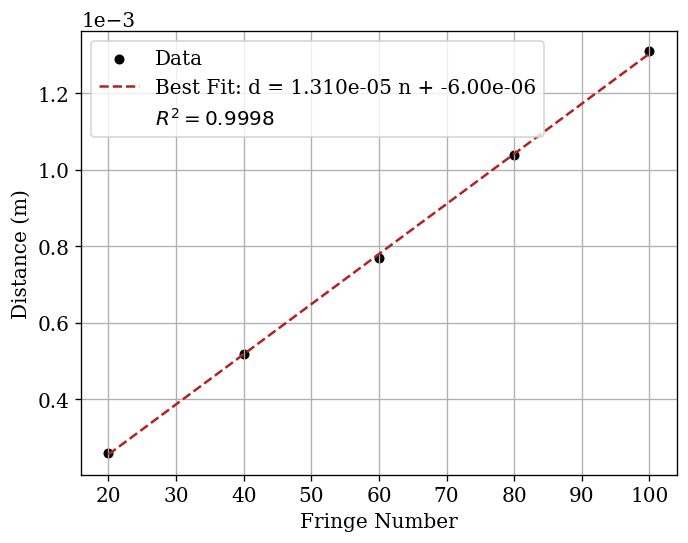

In [115]:
#set1
d1 = np.array([26,52,77,104,131])
s1 = plotw(d1)
w1 = findwav(s1)
print(w1)

6.4347e-07


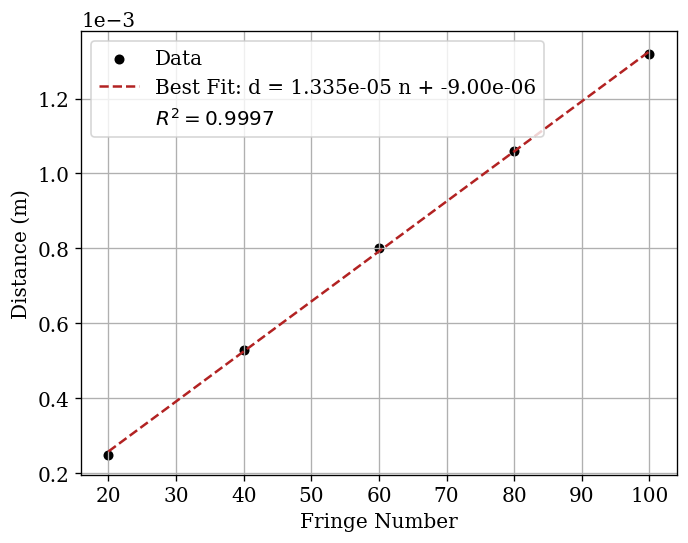

In [116]:
#set2
d2 = np.array([25,53,80,106,132])
s2 = plotw(d2)
w2 = findwav(s2)
print(w2)
plt.savefig("slopefringe.jpg")

6.193700000000001e-07


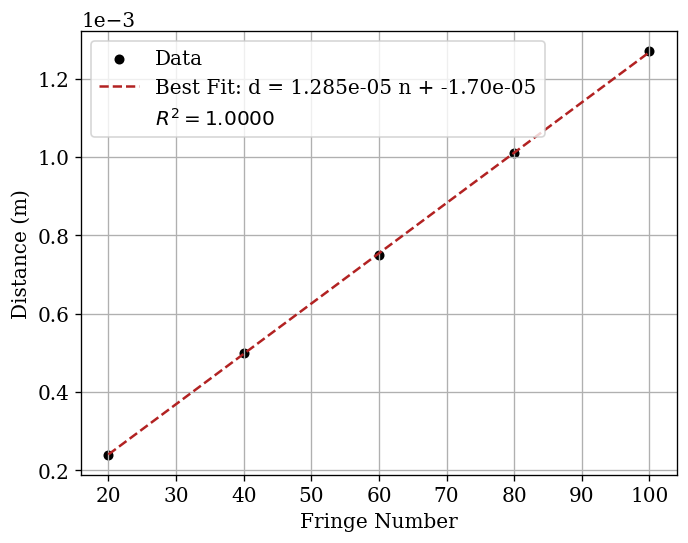

In [117]:
#set3
d3 = np.array([24,50,75,101,127])
s3 = plotw(d3)
w3 = findwav(s3)
print(w3)

In [118]:
#mean wavelength for Part I - A
meanw = (w1+w2+w3)/3
print(meanw)

w_relerr = (650e-9 - meanw)/650e-9 * 100
print(str(w_relerr.round(2))+"% relative error")

6.3142e-07
2.86% relative error


## b) With Glass Slide

In [119]:
def findRI(i, N, w):
    #takes angle value array i in degrees, fringe array N and wavelength value obtained from Part I. 
    #Converts i to rad, subtracts reference i value and then calculates refractive index
    i_0 = np.deg2rad(271) #Initial Reference in radians
    T_0 = 1.02e-3 #Thickness of glass plate in m
    i = np.deg2rad(i)
    di = i-i_0 #subtracted from ref
    numerator = ((2*T_0)-(N*w))*(1-np.cos(di))
    denominator = ((2*T_0)*(1-np.cos(di))) - (N*w)
    plt.scatter(denominator,numerator,label="Data",c='blue')
    n = numerator/denominator #n is refractive index
    m,c = np.polyfit(denominator, numerator, deg = 1)
    y_fit = m*denominator + c
    rsqare = rsq(numerator, y_fit)
    plt.plot(denominator, y_fit, ls="--", c='k',label=fr"Best Fit: d = {m:.3f} n + {abs(c):.2f}")
    plt.plot([], [], ' ', label=fr"$R^2 = {rsqare:.4f}$")
    plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
    plt.ylabel(r"$[2t\ - \ N\lambda][1 - \cos i] \ (m)$")
    plt.xlabel(r"$2t \ [1 - \cos i] - N\lambda \ (m)$")
    plt.grid()
    plt.legend()
    print(m)
    return m

1.445524115257813


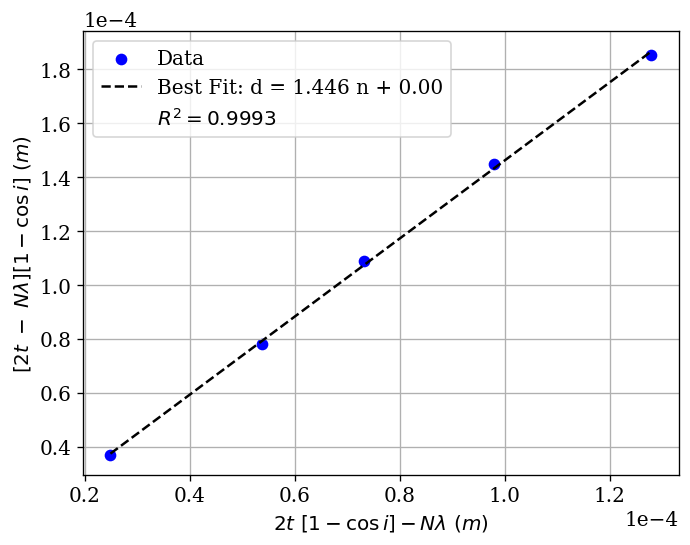

In [120]:
#set1
i_1 = np.array([260,255,252,249,246])
N = np.arange(20,20*len(i_1)+10,20)
n1 = findRI(i_1, N=N, w=meanw)

1.442181096972735


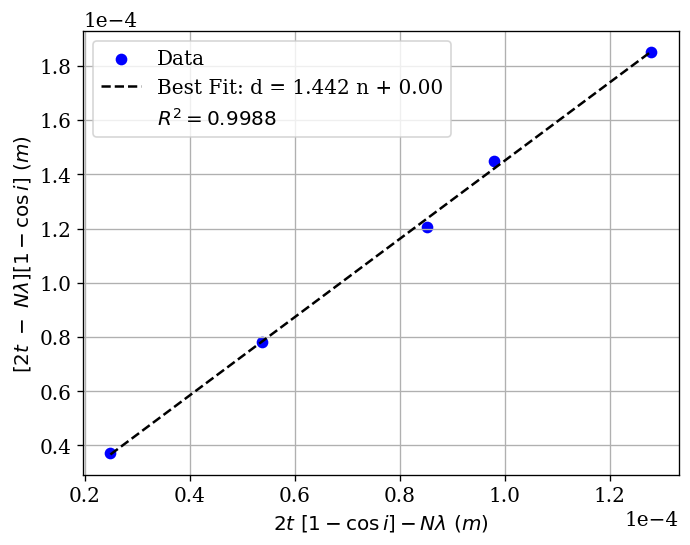

In [121]:
#set2
i_2 = np.array([260,255,251,249,246])
n2 = findRI(i_2, N=N, w=meanw)

1.456983401452146


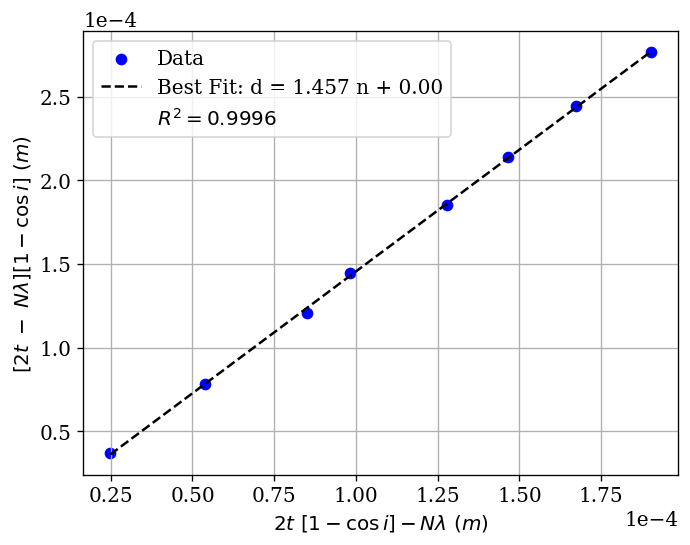

In [122]:
#set3
i_3 = np.array([260,255,251,249,246,244,242,240])
N = np.arange(20,20*len(i_3)+10,20)
n3 = findRI(i_3, N=N, w = meanw)
# plt.savefig("refindexslope.jpg")

In [123]:
#mean refractive index of glass
n_mean = (n1+n2+n3)/3
print(n_mean.round(3))

n_relerr = (1.52 - n_mean)/1.52 * 100
print(str(n_relerr.round(2))+"% relative error")

1.448
4.72% relative error


# Part III - Brewster's Angle

In [124]:
#TestingData
# theta_par1 = np.array([20,24,28,32,36,40,44,48,52,56,60,64,68,72])
# intensity_par1 = np.array([0.3,0.5,0.8,0.7,0.6,0.3,0.3,0.2,0.04,0.01,0.027,0.1,0.9,1.3])

In [125]:
def plotint(theta, intensity, c="k"):
    theta = np.array(theta)
    intensity = np.array(intensity)
    plt.scatter(theta,intensity,c=c,s=20,label="Data")
    plt.xlabel(r"Angle $\mathrm{\theta}$ (deg)")
    plt.ylabel("Intensity (mA)")
    plt.grid(alpha=0.1)
    plt.legend()

54.90981963927855
0.9668493008411698
1.4233745612439659


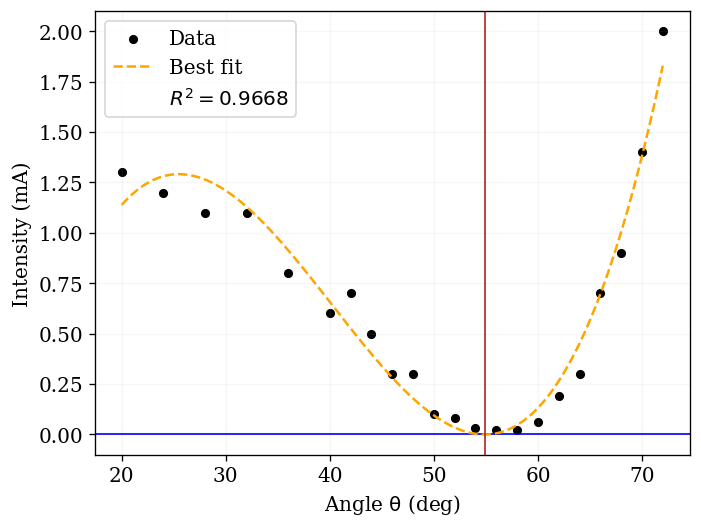

In [126]:
#Max intensity was 16.2
theta_par2 = np.array([20,24,28,32,36,40,42,44,46,48,50,52,54,56,58,60,62,64,66,68,70,72])
int_par2 = np.array([1.3,1.2,1.1,1.1,0.8,0.6,0.7,0.5,0.3,0.3,0.1,0.08,0.032,0.022,0.02,0.062,0.188,0.3,0.7,0.9,1.4,2]) 
plotint(theta_par2, int_par2)
plt.axhline(0.004,c="blue",lw=1)
# plt.axvline(58,c="firebrick",lw=1)

cs = UnivariateSpline(theta_par2, int_par2, s=0.5)
x_new = np.linspace(min(theta_par2), max(theta_par2), 500)
y_new = cs(x_new) 
plt.plot(x_new, y_new, label='Best fit', color='orange',ls="--")

# plt.xlim(50,60)

min_ind = np.argmin(y_new)
brewster = x_new[min_ind]
print(brewster)
plt.axvline(brewster,c="firebrick",lw=1)

#R^2 value
y_new2 = cs(theta_par2) 
curversq = rsq(int_par2,y_new2)
print(curversq)
plt.plot([], [], ' ', label=fr"$R^2 = {curversq:.4f}$")

plt.legend()
# plt.savefig("ParallelBrews.jpg")
print(np.tan(np.radians(brewster)))

0.984280967619868


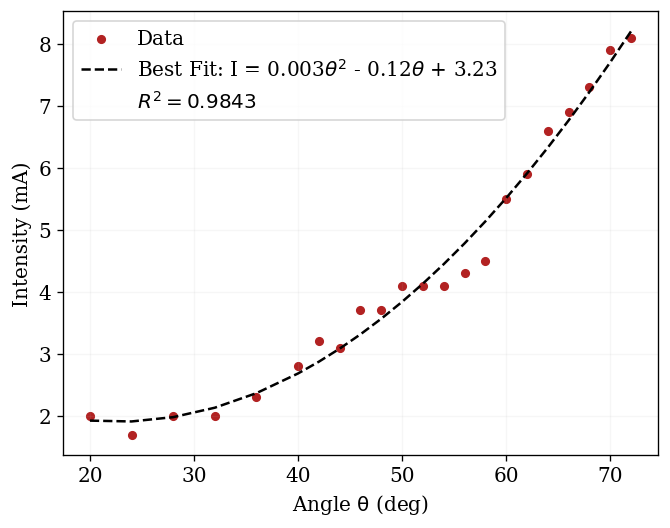

In [127]:
#Max Intensity was 20.2
theta_perp3 = np.array([20,24,28,32,36,40,42,44,46,48,50,52,54,56,58,60,62,64,66,68,70,72])
int_perp3 = np.array([2,1.7,2,2,2.3,2.8,3.2,3.1,3.7,3.7,4.1,4.1,4.1,4.3,4.5,5.5,5.9,6.6,6.9,7.3,7.9,8.1])
plotint(theta_perp3,int_perp3,c="firebrick")

#Best fit:
a_1,b_1,c_1 = np.polyfit(theta_perp3,int_perp3,deg=2)
yfitb1 = a_1*theta_perp3**2 + b_1*theta_perp3 + c_1
plt.plot(theta_perp3,yfitb1,ls="--",c='k',label=fr'Best Fit: I = {a_1:.3f}$\theta ^2$ - {abs(b_1):.2f}$\theta$ + {c_1:.2f}')


#Rsquare:
rsqval1 = rsq(int_perp3,yfitb1)
print(rsqval1)
plt.plot([], [], ' ', label=fr"$R^2 = {rsqval1:.4f}$")

plt.legend()
# plt.savefig("Perpbrews.jpg")

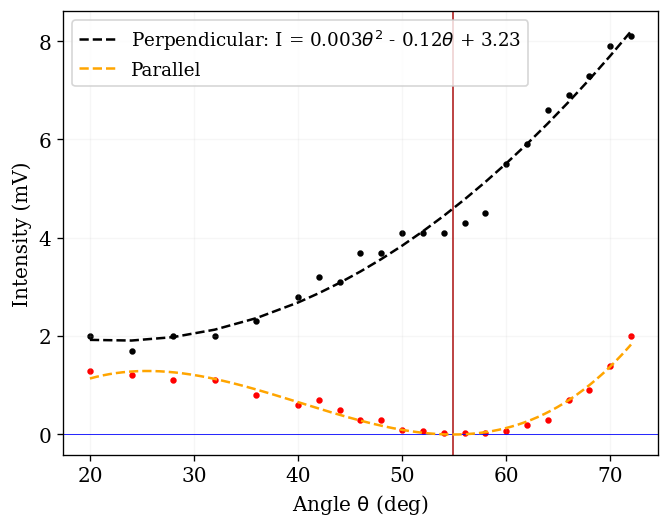

In [128]:
plt.scatter(theta_par2,int_par2,c="red",s=8)
plt.scatter(theta_perp3,int_perp3,c='k',s=8)
plt.axhline(0.005,c="blue",lw=0.5)
plt.axvline(brewster,c="firebrick",lw=1)
plt.plot(theta_perp3,yfitb1,ls="--",c='k',label=fr'Perpendicular: I = {a_1:.3f}$\theta ^2$ - {abs(b_1):.2f}$\theta$ + {c_1:.2f}')
plt.plot(x_new, y_new, label='Parallel', color='orange',ls="--")
plt.xlabel(r"Angle $\mathrm{\theta}$ (deg)")
plt.ylabel("Intensity (mV)")
plt.grid(alpha=0.1)
plt.legend(prop={'size':11})
# plt.savefig("Brewstogether.jpg")

# Part II - Malus' Law

In [129]:
def cos2_model(x, A, omega, phi, C):
    return A * np.cos(omega * x + phi)**2 + C

In [130]:
from scipy.optimize import curve_fit

def fit_cos2(x, y, p0=None, bounds=(-np.inf, np.inf)):
    if p0 is None:
        A0 = (y.max() - y.min())
        C0 = y.min()
        omega0 = 2 * np.pi / (x.max() - x.min())
        phi0 = 0.0
        p0 = (A0, omega0, phi0, C0)

    popt, pcov = curve_fit(
        cos2_model,
        x,
        y,
        p0=p0,
        bounds=bounds
    )
    return popt, pcov

In [131]:
Malustheta = np.array([45,46,48,50,52,54,56,58,60,62,64,66,68,70,72,74,
                       76,78,80,82,84,86,88,90,92,94,96,98,100,102,104,106,108,110,112,114,116,
                       118,120,122,124,126,128,130,132,134,136,138,140,142,144,146,148,150,
                       152,154,156,158,160,162,164,166,168,170,172,174,176,178,180
                      ])
Malusintensity = np.array([0,0,0.047,0.125,0.3,0.5,0.7,1.1,1.4,1.8,2.1,2.7,3.1,3.7,4.2,4.7,5.5,6,6.8,
                           7.3,7.9,8.4,8.9,9.5,10.2,11.1,11.6,11.9,12.3,13,13.8,14.5,14.8,15.1,15.4,16.1,16.7,
                           17.2,17.5,17.6,17.6,18,18.2,18.5,18.5,18.3,18,18,18,18,18.1,17.7,17.4,17.2,
                           16.9,16.9,16.8,16.4,16.4,15.8,15.1,14.4,13.6,13,12.3,11.6,11,10.5,9.8
                          ])
Mtheta = np.array([182,184,186,188,190,192,194,196,198,200,202,204,206,208,210,212,214,216,218,
                   220,222,224,226,228,230,232,234,236,238,240, 242,244,246,248,250,
                   252,254,256,258,260,262,264,266,268,270,272,274,276,278,280,282,284,
                   286,288,290,292,294,296,298,300,302,304,306,308,310,312,314,316,
                   318,320,322,324,326,328,330,332,334,336,338,340,342,344,346,348,350,
                   352,354,356,358,360,362,364,366,368,370,372,374,376,378,380,382,384,386,
                   388,390,392,394,396,398,400,402,404,405
                  ])
Mint = np.array([9.3,8.7,8,7.4,6.7,6.2,5.1,4.7,4.1,3.7,3.1,2.6,2.2,1.7,1.3,1,0.6,0.4,0.3,
                0.1,0.045,0.0045,0.005,0.03,0.11,0.3,0.5,0.8,1.1,1.5,1.9,2.3,2.8,3.4,3.9,
                 4.6,5.1,5.6,6.1,6.6,7.4,8.1,8.9,9.8,10.8,11.9,12.5,13.2,13.6,13.9,14.1,14.6,
                 15.5,16.2,16.6,17,17.7,18.5,18.7,18.8,19.7,20.2,20.6,20.9,20.8,20.6,20.1,19.7,
                 19.6,19.3,18.7,18.4,18.8,19.3,19.6,18.8,17.9,17.2,16.7,16.4,16.1,15.5,15.2,14.8,14.4,
                 13.7,13.3,12.4,11.3,10.6,10,9.3, 8.8,8.1,7.3,6.6,5.8,5,4.5,4,3.3,2.9,2.4,
                 1.9,1.6,1.1,0.8,0.5,0.3,0.2,0.1,0.02,0.0039
                ])
#Adding lists:
x_cos = np.concatenate((Malustheta,Mtheta))
y_cos = np.concatenate((Malusintensity,Mint))

0.9913795628148325


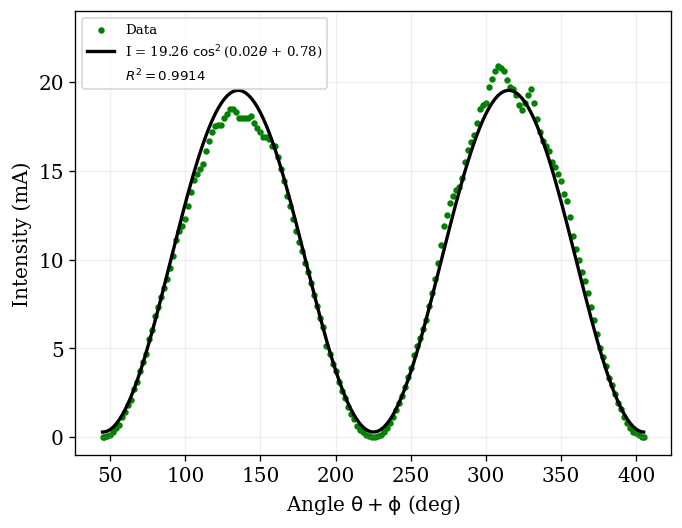

In [132]:
#Performing fit using defined functions
params, covariance = fit_cos2(x_cos, y_cos)
A, omega, phi, C = params
y_fitcos = cos2_model(x_cos, *params)

plt.scatter(x_cos, y_cos, label="Data", s=8,c='green')
plt.plot(x_cos, y_fitcos, label=fr"I = {A:.2f}$\ \cos^2$({omega:.2f}$\theta$ + {phi:.2f})", linewidth=2,c='k')
plt.grid(alpha=0.2)
plt.xlabel(r"Angle $\mathrm{\theta + \phi}$ (deg)")
plt.ylabel("Intensity (mA)")
plt.ylim(-1,24)
# plt.show()
cosrsq = rsq(y_cos, y_fitcos)
print(cosrsq)
plt.plot([], [], ' ', label=fr"$R^2 = {cosrsq:.4f}$")

plt.legend(loc=2, prop={'size': 8})
# plt.savefig("maluslaw.jpg")